<a href="https://colab.research.google.com/github/iqlore-collab/SUPERVISED-MASHINE-LEARNING-/blob/main/02_decision_tree_housing_EN_github_practical_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Housing Classification — From a Simple Tree to a Practical Model

This notebook builds a binary classification model for housing data.

Goal:

- `Expensive = 0` — the house is not expensive,
- `Expensive = 1` — the house is expensive.

Workflow:

1. start with a baseline,
2. train a simple `max_depth=3` decision tree,
3. check whether the model detects `Expensive = 1`,
4. test different `max_depth` values,
5. add `class_weight="balanced"`,
6. choose a more practical final model.


## 1. Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt


## 2. Load data from Google Drive

In [2]:
file_id = "1nfBXyf1_yJmHnRTp4Xeyz0zGDhCNdpUy"
url = f"https://drive.google.com/uc?id={file_id}"

df = pd.read_csv(url)

df.head()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
0,8450,65.0,856,3,0,0,2,0,0,0
1,9600,80.0,1262,3,1,0,2,298,0,0
2,11250,68.0,920,3,1,0,2,0,0,0
3,9550,60.0,756,3,1,0,3,0,0,0
4,14260,84.0,1145,4,1,0,3,192,0,0


## 3. Quick data exploration

In [3]:
print("Rozmiar danych:", df.shape)
print("\nKolumny:")
print(df.columns.tolist())

df.info()


Rozmiar danych: (1460, 10)

Kolumny:
['LotArea', 'LotFrontage', 'TotalBsmtSF', 'BedroomAbvGr', 'Fireplaces', 'PoolArea', 'GarageCars', 'WoodDeckSF', 'ScreenPorch', 'Expensive']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   LotArea       1460 non-null   int64  
 1   LotFrontage   1201 non-null   float64
 2   TotalBsmtSF   1460 non-null   int64  
 3   BedroomAbvGr  1460 non-null   int64  
 4   Fireplaces    1460 non-null   int64  
 5   PoolArea      1460 non-null   int64  
 6   GarageCars    1460 non-null   int64  
 7   WoodDeckSF    1460 non-null   int64  
 8   ScreenPorch   1460 non-null   int64  
 9   Expensive     1460 non-null   int64  
dtypes: float64(1), int64(9)
memory usage: 114.2 KB


In [4]:
df.describe()


,LotArea,LotFrontage,TotalBsmtSF,BedroomAbvGr,Fireplaces,PoolArea,GarageCars,WoodDeckSF,ScreenPorch,Expensive
count,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,10516.828082,70.049958,1057.429452,2.866438,0.613014,2.758904,1.767123,94.244521,15.060959,0.148630
std,9981.264932,24.284752,438.705324,0.815778,0.644666,40.177307,0.747315,125.338794,55.757415,0.355845
min,1300.000000,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7553.500000,59.000000,795.750000,2.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,9478.500000,69.000000,991.500000,3.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000
75%,11601.500000,80.000000,1298.250000,3.000000,1.000000,0.000000,2.000000,168.000000,0.000000,0.000000
max,215245.000000,313.000000,6110.000000,8.000000,3.000000,738.000000,4.000000,857.000000,480.000000,1.000000


In [5]:
missing_values = df.isna().sum().sort_values(ascending=False)
missing_values


,0
LotFrontage,259
LotArea,0
TotalBsmtSF,0
BedroomAbvGr,0
Fireplaces,0
PoolArea,0
GarageCars,0
WoodDeckSF,0
ScreenPorch,0
Expensive,0


The missing values are in `LotFrontage`.

Since scikit-learn's `DecisionTreeClassifier` does not handle `NaN`, we need imputation before training.

## 4. Features and target

In [6]:
target = "Expensive"

features = [
    "LotArea",
    "LotFrontage",
    "TotalBsmtSF",
    "BedroomAbvGr",
    "Fireplaces",
    "PoolArea",
    "GarageCars",
    "WoodDeckSF",
    "ScreenPorch",
]

X = df[features]
y = df[target]

print("X:", X.shape)
print("y:", y.shape)


X: (1460, 9)
y: (1460,)


## 5. Class imbalance

In [7]:
class_summary = pd.DataFrame({
    "count": y.value_counts().sort_index(),
    "percent": (y.value_counts(normalize=True).sort_index() * 100).round(2)
})

class_summary


,count,percent
Expensive,,
0,1243,85.14
1,217,14.86


The classes are imbalanced: most observations are `Expensive = 0`.

Therefore, accuracy alone can be misleading. We will also track:

- `balanced_accuracy`,
- `precision`,
- `recall`,
- `f1`.

For this problem, recall for class `1` is especially important:

> how many expensive houses the model can find.

## 6. Train/test split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (1168, 9)
Test: (292, 9)


## 7. Missing values — median imputation

In [9]:
imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_imputed = pd.DataFrame(X_train_imputed, columns=features, index=X_train.index)
X_test_imputed = pd.DataFrame(X_test_imputed, columns=features, index=X_test.index)

print("Braki w X_train po imputacji:", X_train_imputed.isna().sum().sum())
print("Braki w X_test po imputacji:", X_test_imputed.isna().sum().sum())


Braki w X_train po imputacji: 0
Braki w X_test po imputacji: 0


## 8. Model evaluation helper function

In [10]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    result = {
        "model": name,
        "train_accuracy": accuracy_score(y_train, y_pred_train),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
        "precision_1": precision_score(y_test, y_pred_test, zero_division=0),
        "recall_1": recall_score(y_test, y_pred_test, zero_division=0),
        "f1_1": f1_score(y_test, y_pred_test, zero_division=0)
    }

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
        result["roc_auc"] = roc_auc_score(y_test, y_score)
    else:
        result["roc_auc"] = np.nan

    return result, y_pred_test


## 9. Baseline

In [11]:
baseline = DummyClassifier(strategy="most_frequent")

baseline_result, y_pred_baseline = evaluate_model(
    "Baseline: most frequent",
    baseline,
    X_train_imputed,
    X_test_imputed,
    y_train,
    y_test
)

pd.DataFrame([baseline_result]).round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.851,0.8527,0.5,0.0,0.0,0.0,0.5


The baseline has high accuracy because most houses belong to class `0`.

However, it does not detect class `1`, so it is not a useful practical model.

## 10. First model: simple `max_depth=3` tree

In [12]:
tree_depth_3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_depth_3_result, y_pred_depth_3 = evaluate_model(
    "Decision Tree: max_depth=3",
    tree_depth_3,
    X_train_imputed,
    X_test_imputed,
    y_train,
    y_test
)

pd.DataFrame([baseline_result, tree_depth_3_result]).round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000
1,Decision Tree: max_depth=3,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732


`max_depth=3` is a good starting model:

- simple,
- easy to visualize,
- easy to explain,
- often better than the baseline.

But this does not mean it is the best practical model.

## 11. Confusion matrix for `max_depth=3`

In [13]:
cm_depth_3 = confusion_matrix(y_test, y_pred_depth_3)

cm_depth_3_df = pd.DataFrame(
    cm_depth_3,
    index=["Rzeczywiste 0", "Rzeczywiste 1"],
    columns=["Predykcja 0", "Predykcja 1"]
)

cm_depth_3_df


,Predykcja 0,Predykcja 1
Rzeczywiste 0,239,10
Rzeczywiste 1,17,26


In [14]:
print(classification_report(y_test, y_pred_depth_3, zero_division=0))


              precision    recall  f1-score   support

           0       0.93      0.96      0.95       249
           1       0.72      0.60      0.66        43

    accuracy                           0.91       292
   macro avg       0.83      0.78      0.80       292
weighted avg       0.90      0.91      0.90       292



## 12. Visualize the `max_depth=3` tree

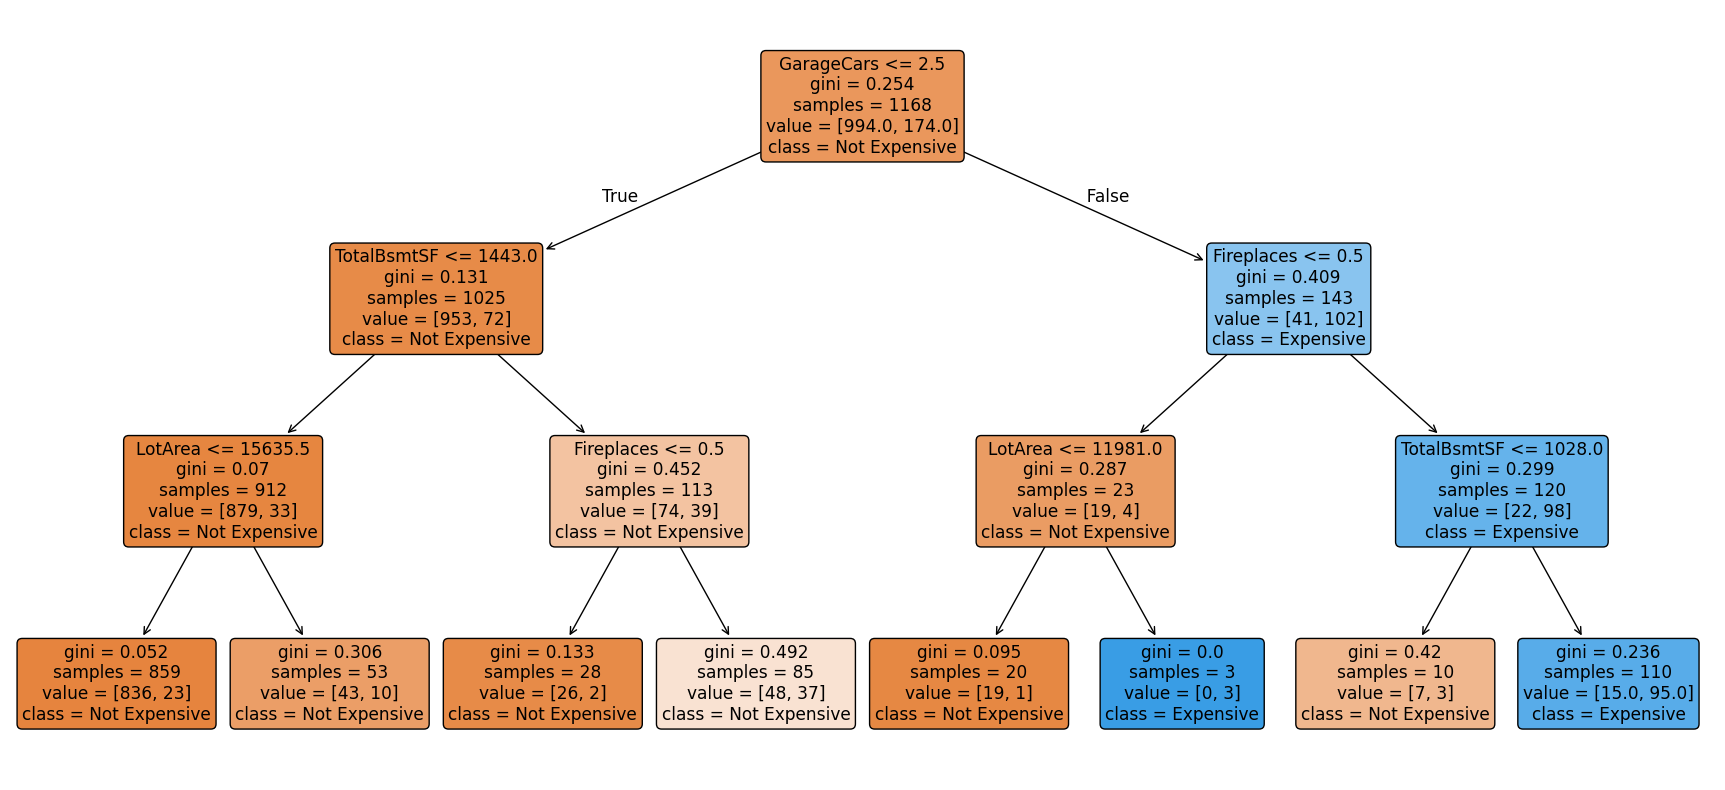

In [15]:
plt.figure(figsize=(22, 10))

plot_tree(
    tree_depth_3,
    feature_names=features,
    class_names=["Not Expensive", "Expensive"],
    filled=True,
    rounded=True
)

plt.show()


## 13. Experiment: different `max_depth` values

In [16]:
depth_results = []

for depth in [1, 2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    result, _ = evaluate_model(
        f"Decision Tree: max_depth={depth}",
        model,
        X_train_imputed,
        X_test_imputed,
        y_train,
        y_test
    )

    result["max_depth"] = depth
    depth_results.append(result)

depth_df = pd.DataFrame(depth_results)

depth_df[[
    "max_depth",
    "train_accuracy",
    "test_accuracy",
    "balanced_accuracy",
    "precision_1",
    "recall_1",
    "f1_1",
    "roc_auc"
]].round(4)


,max_depth,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,1.0,0.9033,0.8904,0.7818,0.6279,0.6279,0.6279,0.7818
1,2.0,0.9161,0.9110,0.7939,0.7297,0.6279,0.6750,0.8782
2,3.0,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732
3,4.0,0.9315,0.9110,0.7843,0.7429,0.6047,0.6667,0.8940
4,5.0,0.9469,0.9315,0.8636,0.7674,0.7674,0.7674,0.8750
5,6.0,0.9529,0.9247,0.8404,0.7561,0.7209,0.7381,0.9026
6,8.0,0.9717,0.9178,0.8171,0.7436,0.6744,0.7073,0.8416
7,10.0,0.9846,0.9075,0.8111,0.6905,0.6744,0.6824,0.8184
8,NaN,1.0000,0.9041,0.8187,0.6667,0.6977,0.6818,0.8187


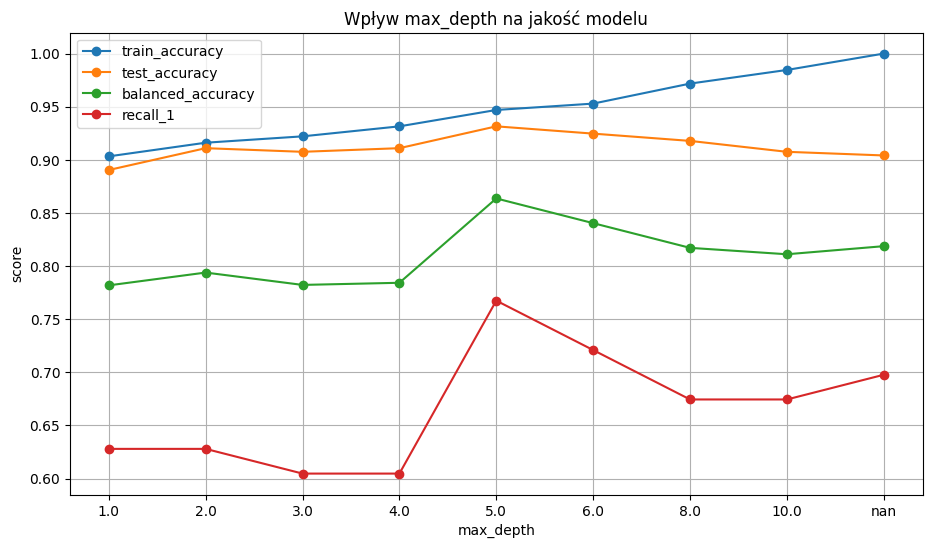

In [17]:
depth_plot_df = depth_df.copy()
depth_plot_df["max_depth_label"] = depth_plot_df["max_depth"].astype(str)

depth_plot_df.plot(
    x="max_depth_label",
    y=["train_accuracy", "test_accuracy", "balanced_accuracy", "recall_1"],
    figsize=(11, 6),
    marker="o"
)

plt.title("Wpływ max_depth na jakość modelu")
plt.xlabel("max_depth")
plt.ylabel("score")
plt.grid(True)
plt.show()


Here we can see that increasing `max_depth` does not always improve the model.

As depth grows:
- training accuracy usually increases,
- test accuracy may stop improving,
- the model may start overfitting.

Therefore, `max_depth` should be selected based on metrics, not intuition.

## 14. Models with `class_weight='balanced'`

In [18]:
balanced_depth_results = []

for depth in [2, 3, 4, 5, 6, 8, 10, None]:
    model = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42
    )

    result, _ = evaluate_model(
        f"Balanced Tree: max_depth={depth}",
        model,
        X_train_imputed,
        X_test_imputed,
        y_train,
        y_test
    )

    result["max_depth"] = depth
    balanced_depth_results.append(result)

balanced_depth_df = pd.DataFrame(balanced_depth_results)

balanced_depth_df[[
    "max_depth",
    "train_accuracy",
    "test_accuracy",
    "balanced_accuracy",
    "precision_1",
    "recall_1",
    "f1_1",
    "roc_auc"
]].round(4)


,max_depth,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,2.0,0.8733,0.8562,0.8483,0.5070,0.8372,0.6316,0.8782
1,3.0,0.9050,0.9075,0.8688,0.6481,0.8140,0.7216,0.9120
2,4.0,0.8973,0.8938,0.8704,0.6000,0.8372,0.6990,0.9219
3,5.0,0.8459,0.8185,0.8455,0.4419,0.8837,0.5891,0.9147
4,6.0,0.8998,0.8699,0.8564,0.5373,0.8372,0.6545,0.9040
5,8.0,0.8913,0.8253,0.8303,0.4500,0.8372,0.5854,0.9039
6,10.0,0.8998,0.8390,0.8383,0.4737,0.8372,0.6050,0.9045
7,NaN,0.8998,0.8390,0.8383,0.4737,0.8372,0.6050,0.9045


`class_weight="balanced"` increases the weight of the minority class `Expensive = 1`.

This often slightly lowers accuracy, but can strongly improve recall for expensive houses.
In practice, this is often a better trade-off.

## 15. Choose the practical model

In [19]:
# Wybieramy model według F1 dla klasy 1.
# Można też wybrać według recall_1, jeśli ważniejsze jest wykrycie jak największej liczby drogich domów.

candidate_results = pd.concat([
    pd.DataFrame([baseline_result, tree_depth_3_result]),
    depth_df,
    balanced_depth_df
], ignore_index=True)

candidate_results_sorted = candidate_results.sort_values(
    by=["f1_1", "balanced_accuracy", "recall_1"],
    ascending=False
)

candidate_results_sorted[[
    "model",
    "train_accuracy",
    "test_accuracy",
    "balanced_accuracy",
    "precision_1",
    "recall_1",
    "f1_1",
    "roc_auc"
]].round(4).head(10)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
6,Decision Tree: max_depth=5,0.9469,0.9315,0.8636,0.7674,0.7674,0.7674,0.8750
7,Decision Tree: max_depth=6,0.9529,0.9247,0.8404,0.7561,0.7209,0.7381,0.9026
12,Balanced Tree: max_depth=3,0.9050,0.9075,0.8688,0.6481,0.8140,0.7216,0.9120
8,Decision Tree: max_depth=8,0.9717,0.9178,0.8171,0.7436,0.6744,0.7073,0.8416
13,Balanced Tree: max_depth=4,0.8973,0.8938,0.8704,0.6000,0.8372,0.6990,0.9219
9,Decision Tree: max_depth=10,0.9846,0.9075,0.8111,0.6905,0.6744,0.6824,0.8184
10,Decision Tree: max_depth=None,1.0000,0.9041,0.8187,0.6667,0.6977,0.6818,0.8187
3,Decision Tree: max_depth=2,0.9161,0.9110,0.7939,0.7297,0.6279,0.6750,0.8782
5,Decision Tree: max_depth=4,0.9315,0.9110,0.7843,0.7429,0.6047,0.6667,0.8940
1,Decision Tree: max_depth=3,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732


In practice, we should not select the model only by accuracy.

For this problem, a good model should:
- keep reasonable accuracy,
- have high balanced accuracy,
- detect `Expensive = 1`,
- avoid excessive overfitting.

In this notebook, the final candidate is a balanced tree with limited depth and `min_samples_leaf=10`.

## 16. Final practical model

In [20]:
final_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

final_result, y_pred_final = evaluate_model(
    "Final practical model: balanced tree, max_depth=4",
    final_model,
    X_train_imputed,
    X_test_imputed,
    y_train,
    y_test
)

pd.DataFrame([
    baseline_result,
    tree_depth_3_result,
    final_result
]).round(4)


,model,train_accuracy,test_accuracy,balanced_accuracy,precision_1,recall_1,f1_1,roc_auc
0,Baseline: most frequent,0.8510,0.8527,0.5000,0.0000,0.0000,0.0000,0.5000
1,Decision Tree: max_depth=3,0.9221,0.9075,0.7822,0.7222,0.6047,0.6582,0.8732
2,"Final practical model: balanced tree, max_depth=4",0.8973,0.8938,0.8704,0.6000,0.8372,0.6990,0.9219


## 17. Confusion matrix for the final model

In [21]:
cm_final = confusion_matrix(y_test, y_pred_final)

cm_final_df = pd.DataFrame(
    cm_final,
    index=["Rzeczywiste 0", "Rzeczywiste 1"],
    columns=["Predykcja 0", "Predykcja 1"]
)

cm_final_df


,Predykcja 0,Predykcja 1
Rzeczywiste 0,225,24
Rzeczywiste 1,7,36


In [22]:
print(classification_report(y_test, y_pred_final, zero_division=0))


              precision    recall  f1-score   support

           0       0.97      0.90      0.94       249
           1       0.60      0.84      0.70        43

    accuracy                           0.89       292
   macro avg       0.78      0.87      0.82       292
weighted avg       0.92      0.89      0.90       292



## 18. Feature importance of the final model

In [23]:
final_importance_df = pd.DataFrame({
    "feature": features,
    "importance": final_model.feature_importances_
}).sort_values(by="importance", ascending=False)

final_importance_df


,feature,importance
6,GarageCars,0.539855
2,TotalBsmtSF,0.251028
4,Fireplaces,0.124554
0,LotArea,0.057468
7,WoodDeckSF,0.025057
1,LotFrontage,0.002038
3,BedroomAbvGr,0.000000
5,PoolArea,0.000000
8,ScreenPorch,0.000000


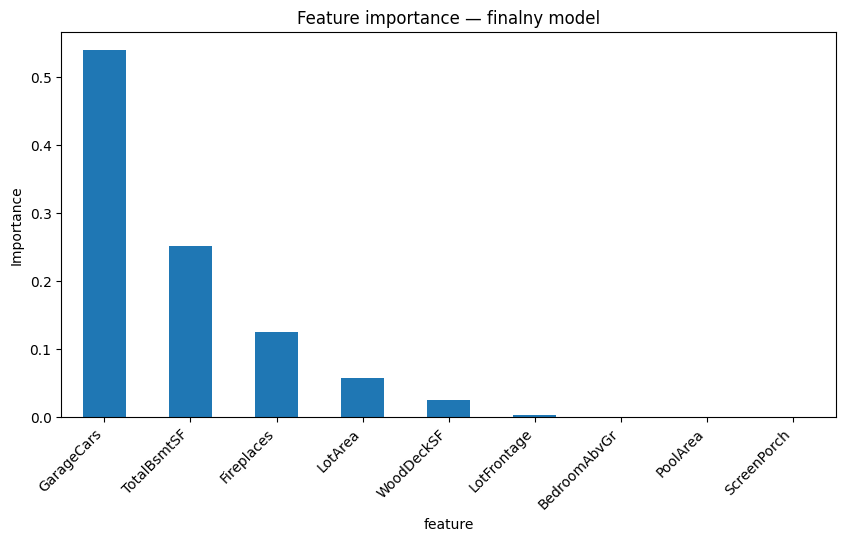

In [24]:
final_importance_df.plot(
    x="feature",
    y="importance",
    kind="bar",
    figsize=(10, 5),
    legend=False
)

plt.title("Feature importance — finalny model")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.show()


## 19. Visualize the final tree

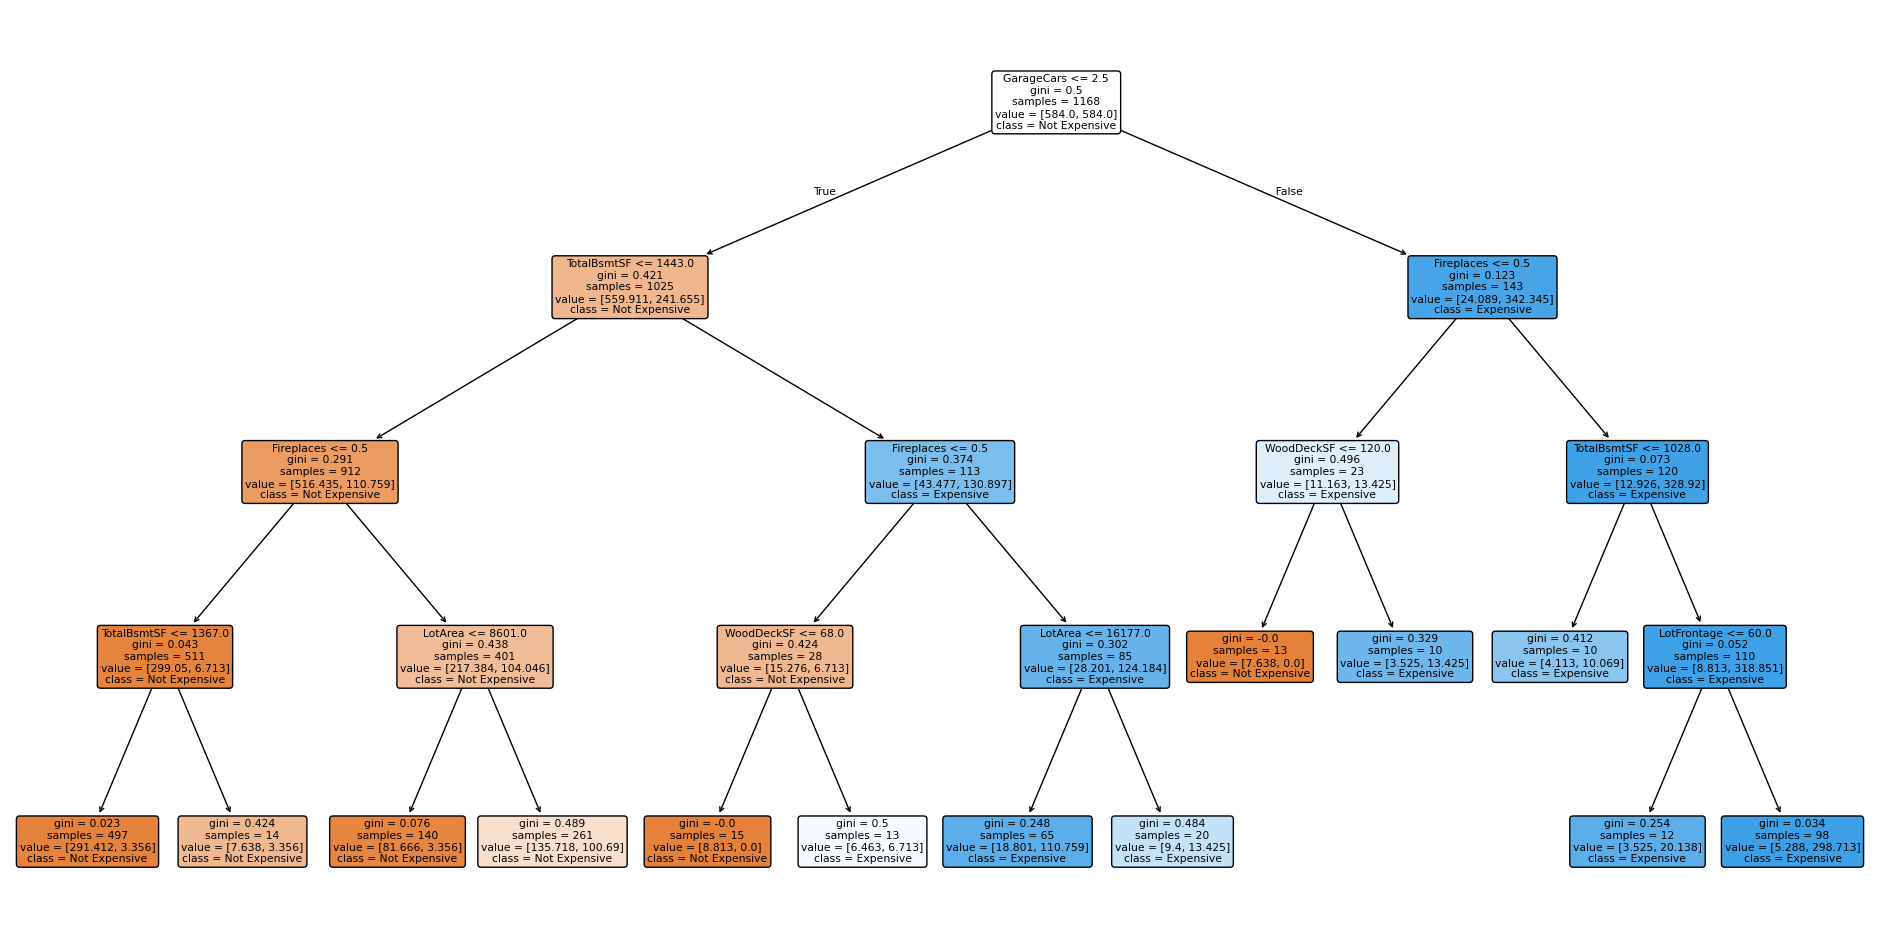

In [25]:
plt.figure(figsize=(24, 12))

plot_tree(
    final_model,
    feature_names=features,
    class_names=["Not Expensive", "Expensive"],
    filled=True,
    rounded=True
)

plt.show()


## 20. Final conclusions

1. `max_depth=3` was a good starting and educational model.
2. Accuracy alone is not enough because the dataset is imbalanced.
3. For a practical model, `recall_1`, `f1_1`, and `balanced_accuracy` are more important.
4. The model with `class_weight="balanced"` detects expensive houses better.
5. The final model uses:
   - `max_depth=4`,
   - `min_samples_leaf=10`,
   - `class_weight="balanced"`.

This model is less simple than the first tree, but more useful in practice.
